# 05: Model Evaluation

## Objective
Evaluate all weekly bed occupancy forecasting models using appropriate metrics and cross-validation techniques.

## Data Source
- **Hospital:** ADVENTHEALTH ORLANDO
- **Date Range:** 2020-07-19 to 2024-04-21 (197 weeks)
- **Target Variable:** `bed_occupancy` (weekly average occupied beds)
- **Train/Test Split:** 157/40 weeks (80/20)

## Tasks
- Gather evaluation metrics from notebooks 04a-04e
- Compare model performance: Baseline, SARIMAX, Structural, VAR, LSTM
- Create comparison table (MAE, RMSE, MAPE, Bias)
- Visualize forecasts vs actual

## Models
- **Baseline** (04a): Seasonal Naive (52-week)
- **SARIMAX** (04b): Seasonal ARIMA with exogenous features
- **Structural** (04c): Unobserved Components Model
- **VAR** (04d): Vector Autoregression (multivariate)
- **LSTM** (04e): Long Short-Term Memory neural network


In [ ]:
# ============================================================================
# PROJECT CONFIGURATION
# ============================================================================
import os

# Setup paths - mount Google Drive if not already mounted (matching notebook 04)
DRIVE_MOUNTED = False
DRIVE_DATA_PROCESSED = None
DRIVE_MODELS_PATH = None
DRIVE_RESULTS_PATH = None

try:
    from google.colab import drive
    # Check if drive is already mounted
    if os.path.exists('/content/drive'):
        DRIVE_MOUNTED = True
        print("✓ Google Drive already mounted")
    else:
        # Mount Google Drive
        print("📁 Mounting Google Drive...")
        drive.mount('/content/drive')
        DRIVE_MOUNTED = True
        print("✓ Google Drive mounted successfully")

    # Set up Google Drive paths
    if DRIVE_MOUNTED:
        DRIVE_ROOT = '/content/drive/MyDrive/hospital_occupancy_forecasting'
        DRIVE_DATA_PROCESSED = os.path.join(DRIVE_ROOT, 'data', 'processed')
        DRIVE_MODELS_PATH = os.path.join(DRIVE_ROOT, 'models')
        DRIVE_RESULTS_PATH = os.path.join(DRIVE_ROOT, 'results', 'visualizations', 'model_evaluation')
        os.makedirs(DRIVE_DATA_PROCESSED, exist_ok=True)
        os.makedirs(DRIVE_MODELS_PATH, exist_ok=True)
        os.makedirs(DRIVE_RESULTS_PATH, exist_ok=True)
        print(f"✓ Google Drive paths configured: {DRIVE_ROOT}")
except ImportError:
    print("ℹ️  Not running in Google Colab (will only check local paths)")
except Exception as e:
    print(f"⚠️  Could not mount Google Drive: {e}")
    print("   Will continue with local Colab paths only")

# Local Colab paths
PROJECT_ROOT = '/content/hospital_occupancy_forecasting'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
DATA_RAW = os.path.join(DATA_DIR, 'raw')
DATA_PROCESSED = os.path.join(DATA_DIR, 'processed')
MODELS_PATH = os.path.join(PROJECT_ROOT, 'models')
RESULTS_PATH = os.path.join(PROJECT_ROOT, 'results', 'visualizations', 'model_evaluation')

for path in [DATA_RAW, DATA_PROCESSED, MODELS_PATH, RESULTS_PATH]:
    os.makedirs(path, exist_ok=True)

# Helper function to save files to both local and Google Drive (matching notebook 04)
def save_file(data, filename, local_path, drive_path=None, **kwargs):
    """
    Save file to both local and Google Drive (if available).

    Args:
        data: Data to save (DataFrame, dict, model, etc.)
        filename: Name of the file
        local_path: Local directory path
        drive_path: Google Drive directory path (optional)
        **kwargs: Additional arguments for save methods (e.g., index=False for to_csv)
    """
    # Save to local
    local_file = os.path.join(local_path, filename)
    if isinstance(data, pd.DataFrame):
        data.to_csv(local_file, **kwargs)
    elif isinstance(data, (dict, list)) and filename.endswith('.json'):
        import json
        with open(local_file, 'w') as f:
            json.dump(data, f, **kwargs)
    elif filename.endswith('.pkl'):
        import pickle
        with open(local_file, 'wb') as f:
            pickle.dump(data, f)
    elif hasattr(data, 'save'):
        data.save(local_file)
    else:
        # Fallback: try to write as text
        with open(local_file, 'w') as f:
            f.write(str(data))
    print(f"✓ Saved to local: {local_file}")

    # Save to Google Drive if available
    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            if isinstance(data, pd.DataFrame):
                data.to_csv(drive_file, **kwargs)
            elif isinstance(data, (dict, list)) and filename.endswith('.json'):
                import json
                with open(drive_file, 'w') as f:
                    json.dump(data, f, **kwargs)
            elif filename.endswith('.pkl'):
                import pickle
                with open(drive_file, 'wb') as f:
                    pickle.dump(data, f)
            elif hasattr(data, 'save'):
                data.save(drive_file)
            else:
                with open(drive_file, 'w') as f:
                    f.write(str(data))
            print(f"✓ Saved to Google Drive: {drive_file}")
        except Exception as e:
            print(f"⚠️  Could not save to Google Drive: {e}")

# Helper function to save plots to both locations (matching notebook 04)
def save_plot(fig, filename, local_path, drive_path=None, **kwargs):
    """Save plot to both local and Google Drive."""
    local_file = os.path.join(local_path, filename)
    fig.savefig(local_file, **kwargs)
    print(f"✓ Saved plot to local: {local_file}")

    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            fig.savefig(drive_file, **kwargs)
            print(f"✓ Saved plot to Google Drive: {drive_file}")
        except Exception as e:
            print(f"⚠️  Could not save plot to Google Drive: {e}")

# Helper function to load file from multiple locations (matching notebook 04)
def load_file(filename, local_path, drive_path=None):
    """
    Load file from local or Google Drive (local priority).

    Returns:
        Loaded data or None if not found
    """
    # Determine if this file should have date parsing
    # Evaluation CSVs have model names as index, not dates
    has_date_index = not ('evaluation' in filename.lower() or 'comparison' in filename.lower())

    # Try local first
    local_file = os.path.join(local_path, filename)
    if os.path.exists(local_file):
        if filename.endswith('.csv'):
            return pd.read_csv(local_file, index_col=0, parse_dates=has_date_index)
        elif filename.endswith('.pkl'):
            import pickle
            with open(local_file, 'rb') as f:
                return pickle.load(f)
        elif filename.endswith('.json'):
            import json
            with open(local_file, 'r') as f:
                return json.load(f)
        elif filename.endswith('.h5'):
            from tensorflow import keras
            return keras.models.load_model(local_file)

    # Try Google Drive if available
    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            if os.path.exists(drive_file):
                if filename.endswith('.csv'):
                    return pd.read_csv(drive_file, index_col=0, parse_dates=has_date_index)
                elif filename.endswith('.pkl'):
                    import pickle
                    with open(drive_file, 'rb') as f:
                        return pickle.load(f)
                elif filename.endswith('.json'):
                    import json
                    with open(drive_file, 'r') as f:
                        return json.load(f)
                elif filename.endswith('.h5'):
                    from tensorflow import keras
                    return keras.models.load_model(drive_file)
        except Exception as e:
            print(f"⚠️  Could not load from Google Drive: {e}")

    return None

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pickle

# Configuration
TRAIN_TEST_SPLIT = 0.8

# Evaluation metrics functions (unified format: MAE, RMSE, MAPE, Bias, n)
def calculate_rmse(actual, predicted):
    """Calculate Root Mean Squared Error"""
    return np.sqrt(mean_squared_error(actual, predicted))

def calculate_mae(actual, predicted):
    """Calculate Mean Absolute Error"""
    return mean_absolute_error(actual, predicted)

def calculate_mape(actual, predicted):
    """Calculate Mean Absolute Percentage Error"""
    mask = actual != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

def calculate_bias(actual, predicted):
    """Calculate Bias (mean error: positive = over-prediction)"""
    return np.mean(predicted - actual)

def calculate_all_metrics(actual, predicted):
    """Calculate all evaluation metrics (unified format)."""
    actual = np.array(actual).flatten()
    predicted = np.array(predicted).flatten()
    return {
        'MAE': calculate_mae(actual, predicted),
        'RMSE': calculate_rmse(actual, predicted),
        'MAPE': calculate_mape(actual, predicted),
        'Bias': calculate_bias(actual, predicted),
        'n': len(actual)
    }



✓ Google Drive already mounted
✓ Google Drive paths configured: /content/drive/MyDrive/hospital_occupancy_forecasting


## Load Test Data and Forecasts


In [ ]:
# Load weekly bed occupancy data (using load_file helper to check both local and Google Drive)
data = load_file('occupancy_with_features.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)

if data is not None:
    train_size = int(len(data) * TRAIN_TEST_SPLIT)
    if 'bed_occupancy' in data.columns:
        test_data = data['bed_occupancy'][train_size:]
    else:
        # Try alternative column names
        occupancy_cols = [c for c in data.columns if 'occupancy' in c.lower() or 'bed' in c.lower()]
        if occupancy_cols:
            test_data = data[occupancy_cols[0]][train_size:]
        else:
            test_data = data.iloc[:, 0][train_size:]
    print(f"Test set: {len(test_data)} weeks")
    print(f"Date range: {test_data.index.min()} to {test_data.index.max()}")
else:
    print("⚠️  occupancy_with_features.csv not found")
    print("   Please run notebooks 01-04 first to create the data.")
    test_data = pd.Series(dtype=float)
    data = None

Test set: 40 weeks
Date range: 2023-07-23 00:00:00 to 2024-04-21 00:00:00


## Gather All Model Evaluations

Load pre-computed evaluation metrics from each model notebook (04a-04e).
Metrics: MAE, RMSE, MAPE (%), Bias, n


In [ ]:
# ============================================================================
# LOAD PRE-COMPUTED MODEL EVALUATIONS FROM INDIVIDUAL NOTEBOOKS
# ============================================================================
# Each model notebook (04a-04e) saves its own evaluation CSV:
#   - baseline_models_evaluation.csv (04a)
#   - sarimax_evaluation.csv (04b)
#   - structural_evaluation.csv (04c)
#   - var_evaluation.csv (04d)
#   - lstm_evaluation.csv (04e)
# NOTE: Only TEST metrics are loaded for comparison

all_evaluations = {}
forecasts = {}

print("="*70)
print("GATHERING MODEL EVALUATIONS FROM NOTEBOOKS 04a-04e")
print("="*70)

# ===== 04a: BASELINE MODELS =====
print("\n📊 04a: Baseline Models")
# Try both filenames (baseline_models_evaluation.csv is the actual filename)
baseline_eval = load_file('baseline_models_evaluation.csv', MODELS_PATH, DRIVE_MODELS_PATH)
if baseline_eval is None:
    baseline_eval = load_file('baseline_evaluation.csv', MODELS_PATH, DRIVE_MODELS_PATH)
if baseline_eval is not None:
    print(f"  ✓ Loaded baseline evaluation")
    for idx in baseline_eval.index:
        # Baseline only has test metrics (no train), label as Test for consistency
        clean_name = str(idx).replace('Seasonal_Naive_', 'SN').replace('seasonal_naive_', 'SN')
        model_name = f"Baseline_{clean_name}_Test"
        all_evaluations[model_name] = baseline_eval.loc[idx].to_dict()
        print(f"    - {model_name}")
else:
    print("  ⚠️ baseline_models_evaluation.csv not found")

# Also try loading baseline forecasts for visualization
baseline_forecasts_df = load_file('baseline_forecasts.csv', MODELS_PATH, DRIVE_MODELS_PATH)
if baseline_forecasts_df is not None and test_data is not None and len(test_data) > 0:
    for col in baseline_forecasts_df.columns:
        try:
            forecast_series = baseline_forecasts_df[col].reindex(test_data.index)
            if not forecast_series.isna().all():
                forecasts[col] = forecast_series
        except:
            pass

# ===== 04b: SARIMAX MODEL =====
print("\n📊 04b: SARIMAX Model")
sarimax_eval = load_file('sarimax_evaluation.csv', MODELS_PATH, DRIVE_MODELS_PATH)
if sarimax_eval is not None:
    print(f"  ✓ Loaded sarimax_evaluation.csv")
    for idx in sarimax_eval.index:
        idx_str = str(idx).lower()
        # Only load test metrics
        if 'train' in idx_str:
            continue
        # Clean up index name
        clean_idx = str(idx).replace('SARIMAX_', '').replace('sarimax_', '').replace('_test', '').replace('test', '')
        model_name = f"SARIMAX_Test"
        all_evaluations[model_name] = sarimax_eval.loc[idx].to_dict()
        print(f"    - {model_name}")
else:
    print("  ⚠️ sarimax_evaluation.csv not found")

# Load SARIMAX forecast for visualization
sarimax_forecast_df = load_file('sarimax_forecast.csv', MODELS_PATH, DRIVE_MODELS_PATH)
if sarimax_forecast_df is not None and test_data is not None and len(test_data) > 0:
    try:
        if 'bed_occupancy' in sarimax_forecast_df.columns:
            forecasts['SARIMAX'] = sarimax_forecast_df['bed_occupancy'].reindex(test_data.index)
        elif 'forecast' in sarimax_forecast_df.columns:
            forecasts['SARIMAX'] = sarimax_forecast_df['forecast'].reindex(test_data.index)
        else:
            forecasts['SARIMAX'] = sarimax_forecast_df.iloc[:, 0].reindex(test_data.index)
    except:
        pass

# ===== 04c: STRUCTURAL STATE-SPACE MODEL =====
print("\n📊 04c: Structural State-Space Model")
structural_eval = load_file('structural_evaluation.csv', MODELS_PATH, DRIVE_MODELS_PATH)
if structural_eval is not None:
    print(f"  ✓ Loaded structural_evaluation.csv")
    for idx in structural_eval.index:
        idx_str = str(idx).lower()
        # Only load test metrics
        if 'train' in idx_str:
            continue
        model_name = f"Structural_Test"
        all_evaluations[model_name] = structural_eval.loc[idx].to_dict()
        print(f"    - {model_name}")
else:
    print("  ⚠️ structural_evaluation.csv not found")

# Load structural forecast for visualization
structural_forecast_df = load_file('structural_forecast.csv', MODELS_PATH, DRIVE_MODELS_PATH)
if structural_forecast_df is not None and test_data is not None and len(test_data) > 0:
    try:
        if 'bed_occupancy' in structural_forecast_df.columns:
            forecasts['Structural'] = structural_forecast_df['bed_occupancy'].reindex(test_data.index)
        elif 'forecast' in structural_forecast_df.columns:
            forecasts['Structural'] = structural_forecast_df['forecast'].reindex(test_data.index)
        else:
            forecasts['Structural'] = structural_forecast_df.iloc[:, 0].reindex(test_data.index)
    except:
        pass

# ===== 04d: VAR MODEL =====
print("\n📊 04d: VAR Model")
var_eval = load_file('var_evaluation.csv', MODELS_PATH, DRIVE_MODELS_PATH)
if var_eval is None:
    var_eval = load_file('var_model_evaluation.csv', MODELS_PATH, DRIVE_MODELS_PATH)
if var_eval is not None:
    print(f"  ✓ Loaded var_evaluation.csv")
    for idx in var_eval.index:
        idx_str = str(idx).lower()
        # Only load test metrics
        if 'train' in idx_str:
            continue
        model_name = f"VAR_Test"
        all_evaluations[model_name] = var_eval.loc[idx].to_dict()
        print(f"    - {model_name}")
else:
    print("  ⚠️ var_evaluation.csv not found")

# Load VAR forecast for visualization
var_forecast_df = load_file('var_forecast.csv', MODELS_PATH, DRIVE_MODELS_PATH)
if var_forecast_df is not None and test_data is not None and len(test_data) > 0:
    try:
        if 'bed_occupancy' in var_forecast_df.columns:
            forecasts['VAR'] = var_forecast_df['bed_occupancy'].reindex(test_data.index)
        else:
            forecasts['VAR'] = var_forecast_df.iloc[:, 0].reindex(test_data.index)
    except:
        pass

# ===== 04e: LSTM MODELS =====
print("\n📊 04e: LSTM Models")
lstm_eval = load_file('lstm_evaluation.csv', MODELS_PATH, DRIVE_MODELS_PATH)
if lstm_eval is not None:
    print(f"  ✓ Loaded lstm_evaluation.csv")
    for idx in lstm_eval.index:
        idx_str = str(idx).lower()
        # Only load test metrics
        if 'train' in idx_str:
            continue
        model_name = f"LSTM_Test"
        all_evaluations[model_name] = lstm_eval.loc[idx].to_dict()
        print(f"    - {model_name}")
else:
    print("  ⚠️ lstm_evaluation.csv not found")

# Load LSTM forecast for visualization
lstm_forecast_df = load_file('enhanced_lstm_forecast.csv', MODELS_PATH, DRIVE_MODELS_PATH)
if lstm_forecast_df is None:
    lstm_forecast_df = load_file('lstm_forecast.csv', MODELS_PATH, DRIVE_MODELS_PATH)
if lstm_forecast_df is not None and test_data is not None and len(test_data) > 0:
    try:
        if 'forecast_median' in lstm_forecast_df.columns:
            forecasts['LSTM'] = lstm_forecast_df['forecast_median'].reindex(test_data.index)
        elif 'bed_occupancy' in lstm_forecast_df.columns:
            forecasts['LSTM'] = lstm_forecast_df['bed_occupancy'].reindex(test_data.index)
        else:
            forecasts['LSTM'] = lstm_forecast_df.iloc[:, 0].reindex(test_data.index)
    except:
        pass

# ===== SUMMARY =====
print("\n" + "="*70)
if len(all_evaluations) > 0:
    print(f"✓ Loaded {len(all_evaluations)} model evaluations")
else:
    print("⚠️ No model evaluations found!")
    print("   Please run notebooks 04a-04e first to generate evaluations.")

GATHERING MODEL EVALUATIONS FROM NOTEBOOKS 04a-04e

📊 04a: Baseline Models
  ✓ Loaded baseline evaluation
    - Baseline_SN52_Test

📊 04b: SARIMAX Model
  ✓ Loaded sarimax_evaluation.csv
    - SARIMAX_Test

📊 04c: Structural State-Space Model
  ✓ Loaded structural_evaluation.csv
    - Structural_Test

📊 04d: VAR Model
  ✓ Loaded var_evaluation.csv
    - VAR_Test

📊 04e: LSTM Models
  ✓ Loaded lstm_evaluation.csv
    - LSTM_Test

✓ Loaded 5 model evaluations


## Create Model Comparison Table


Reference: Mean bed occupancy (test period) = 2366 beds

MODEL COMPARISON - TEST SET PERFORMANCE (sorted by Composite Score)

All error metrics shown as % of mean bed occupancy for interpretability.
Composite Score = average rank across metrics (lower = better)

Model                  MAE (%)    RMSE (%)    MAPE (%)   Bias (%)   Score   
--------------------------------------------------------------------------------
Structural_Test        1.75       2.21        1.74       -0.04      1.00    
Baseline_SN52_Test     1.81       2.35        1.81       -0.22      2.25    
LSTM_Test              1.97       2.31        1.98       +0.47      3.00    
SARIMAX_Test           2.07       2.59        2.06       -0.40      3.75    
VAR_Test               2.97       3.83        2.96       +1.30      5.00    

--------------------------------------------------------------------------------
Raw error values (beds):
Model                  MAE        RMSE       Bias      
-------------------------------

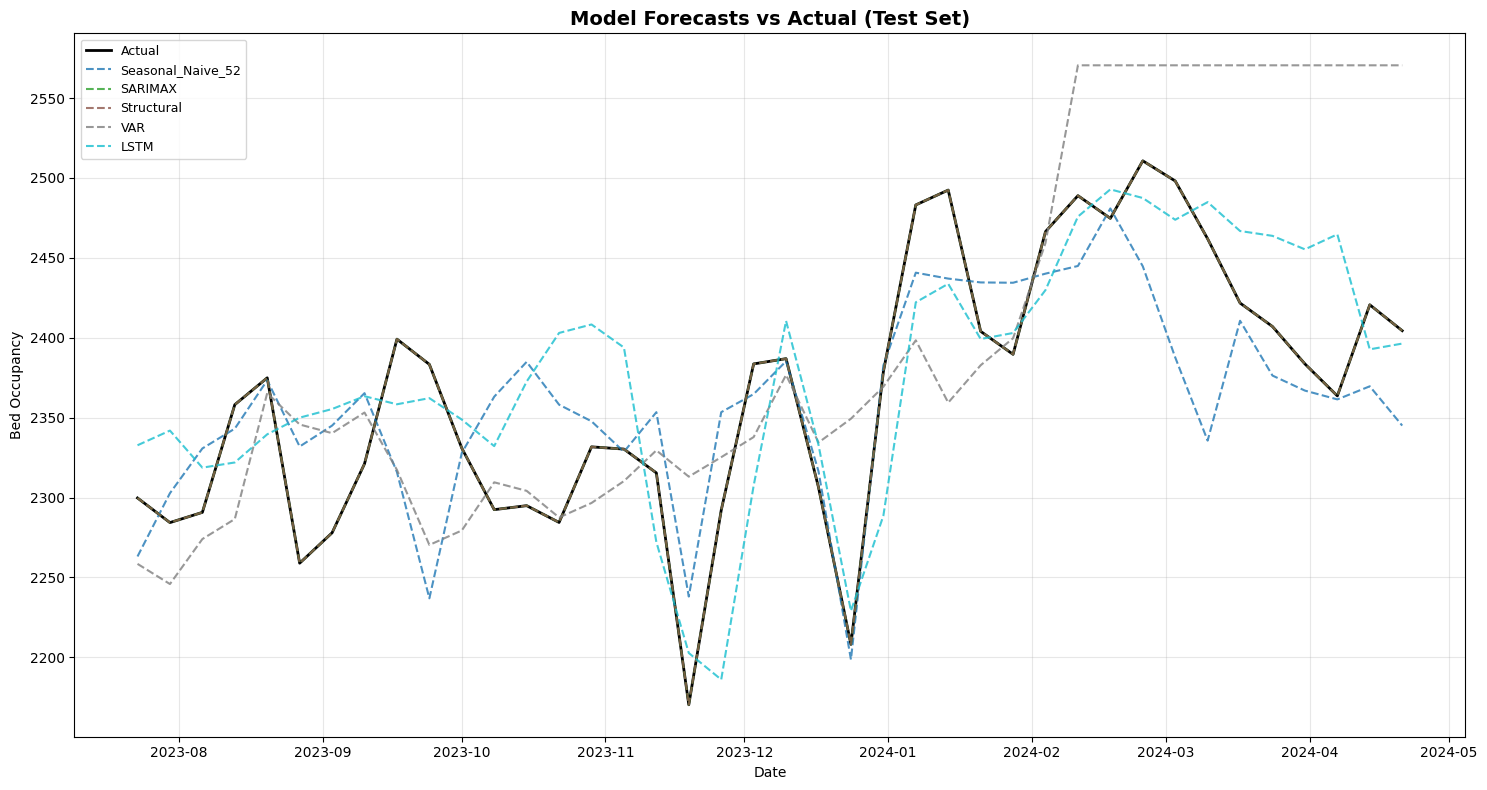

✓ Forecast comparison plot saved


In [ ]:
if len(all_evaluations) > 0:
    # Create comparison DataFrame
    comparison_df = pd.DataFrame(all_evaluations).T

    # Ensure consistent column order (no 'n' column)
    metric_cols = ['MAE', 'RMSE', 'MAPE', 'Bias']
    available_cols = [c for c in metric_cols if c in comparison_df.columns]
    comparison_df = comparison_df[available_cols]

    # Focus on TEST metrics only
    test_rows = comparison_df[comparison_df.index.str.contains('Test', case=False)].copy()

    # ============================================================
    # GET MEAN BED OCCUPANCY FOR NORMALIZATION
    # ============================================================
    # Load test data to get mean occupancy for context
    features_data = load_file('occupancy_with_features.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)
    if features_data is not None and 'bed_occupancy' in features_data.columns:
        # Use last ~40 weeks as test period (matches model notebooks)
        mean_occupancy = features_data['bed_occupancy'].iloc[-40:].mean()
        print(f"Reference: Mean bed occupancy (test period) = {mean_occupancy:.0f} beds\n")
    else:
        mean_occupancy = 2300  # Fallback estimate
        print(f"Reference: Mean bed occupancy (estimated) = {mean_occupancy:.0f} beds\n")

    if len(test_rows) > 0:
        # ============================================================
        # NORMALIZE METRICS AS % OF MEAN OCCUPANCY
        # ============================================================
        # Makes error magnitudes interpretable
        test_rows['MAE (%)'] = (test_rows['MAE'] / mean_occupancy) * 100
        test_rows['RMSE (%)'] = (test_rows['RMSE'] / mean_occupancy) * 100
        test_rows['Bias (%)'] = (test_rows['Bias'] / mean_occupancy) * 100
        # MAPE is already a percentage

        # ============================================================
        # COMPOSITE SCORE CALCULATION
        # ============================================================
        # Uses rank-based scoring on NORMALIZED metrics (lower = better)
        ranks = pd.DataFrame(index=test_rows.index)

        ranks['MAE_rank'] = test_rows['MAE (%)'].rank(ascending=True, na_option='bottom')
        ranks['RMSE_rank'] = test_rows['RMSE (%)'].rank(ascending=True, na_option='bottom')
        ranks['MAPE_rank'] = test_rows['MAPE'].rank(ascending=True, na_option='bottom')
        ranks['Bias_rank'] = test_rows['Bias (%)'].abs().rank(ascending=True, na_option='bottom')

        # Composite score = average rank (lower = better)
        test_rows['Composite'] = ranks.mean(axis=1)

        # Sort by composite score
        test_rows = test_rows.sort_values('Composite')

    print("="*90)
    print("MODEL COMPARISON - TEST SET PERFORMANCE (sorted by Composite Score)")
    print("="*90)
    print("\nAll error metrics shown as % of mean bed occupancy for interpretability.")
    print("Composite Score = average rank across metrics (lower = better)\n")
    print(f"{'Model':<22} {'MAE (%)':<10} {'RMSE (%)':<11} {'MAPE (%)':<10} {'Bias (%)':<10} {'Score':<8}")
    print("-"*80)

    for idx in test_rows.index:
        row = test_rows.loc[idx]
        mae_pct = row.get('MAE (%)', np.nan)
        rmse_pct = row.get('RMSE (%)', np.nan)
        mape = row.get('MAPE', np.nan)
        bias_pct = row.get('Bias (%)', np.nan)
        composite = row.get('Composite', np.nan)

        mae_str = f"{mae_pct:.2f}" if not np.isnan(mae_pct) else "N/A"
        rmse_str = f"{rmse_pct:.2f}" if not np.isnan(rmse_pct) else "N/A"
        mape_str = f"{mape:.2f}" if not np.isnan(mape) else "N/A"
        bias_str = f"{bias_pct:+.2f}" if not np.isnan(bias_pct) else "N/A"  # Show sign
        comp_str = f"{composite:.2f}" if not np.isnan(composite) else "N/A"

        print(f"{idx:<22} {mae_str:<10} {rmse_str:<11} {mape_str:<10} {bias_str:<10} {comp_str:<8}")

    # Also show raw values for reference
    print("\n" + "-"*80)
    print("Raw error values (beds):")
    print(f"{'Model':<22} {'MAE':<10} {'RMSE':<10} {'Bias':<10}")
    print("-"*55)
    for idx in test_rows.index:
        row = test_rows.loc[idx]
        mae = row.get('MAE', np.nan)
        rmse = row.get('RMSE', np.nan)
        bias = row.get('Bias', np.nan)
        mae_str = f"{mae:.1f}" if not np.isnan(mae) else "N/A"
        rmse_str = f"{rmse:.1f}" if not np.isnan(rmse) else "N/A"
        bias_str = f"{bias:+.1f}" if not np.isnan(bias) else "N/A"
        print(f"{idx:<22} {mae_str:<10} {rmse_str:<10} {bias_str:<10}")

    # Save full comparison
    save_file(comparison_df, 'model_comparison_full.csv', RESULTS_PATH, DRIVE_RESULTS_PATH)

    # Save test-only comparison (including composite score and normalized metrics)
    if len(test_rows) > 0:
        save_file(test_rows, 'model_comparison_test.csv', RESULTS_PATH, DRIVE_RESULTS_PATH)

    print(f"\n✓ Comparison tables saved")

    # Best model summary
    if len(test_rows) > 0:
        best_model = test_rows['Composite'].idxmin()
        best_score = test_rows.loc[best_model, 'Composite']
        best_mae_pct = test_rows.loc[best_model, 'MAE (%)']
        print(f"\n🏆 Best Model: {best_model}")
        print(f"   Composite Score: {best_score:.2f}")
        print(f"   Average error: {best_mae_pct:.2f}% of bed occupancy")

    # Visualize forecasts vs actual
    if len(forecasts) > 0 and test_data is not None and len(test_data) > 0:
        plt.figure(figsize=(15, 8))
        plt.plot(test_data.index, test_data.values, label='Actual', color='black', linewidth=2)

        colors = plt.cm.tab10(np.linspace(0, 1, len(forecasts)))
        for i, (name, forecast) in enumerate(forecasts.items()):
            if forecast is not None and not forecast.isna().all():
                plt.plot(forecast.index, forecast.values, label=f'{name}',
                        linestyle='--', alpha=0.8, color=colors[i], linewidth=1.5)

        plt.title('Model Forecasts vs Actual (Test Set)', fontsize=14, fontweight='bold')
        plt.xlabel('Date')
        plt.ylabel('Bed Occupancy')
        plt.legend(loc='best', fontsize=9)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        save_plot(plt.gcf(), 'forecast_comparison.png', RESULTS_PATH, DRIVE_RESULTS_PATH,
                 dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✓ Forecast comparison plot saved")
else:
    print("No model evaluations available yet.")
    print("Please run notebooks 04a-04e first to generate evaluations.")

## Results and Interpretation

### Model Performance Summary

All five forecasting models were evaluated on a 40-week test period using metrics
normalized as percentages of mean bed occupancy (~2,365 beds) for interpretability.

#### Performance Benchmarks for Hospital Capacity Forecasting

| MAE (%) | Interpretation | Operational Implication |
|---------|----------------|-------------------------|
| < 2%    | **Excellent**  | Highly reliable for staffing decisions |
| 2-5%    | **Good**       | Suitable for operational planning |
| 5-10%   | **Acceptable** | Use with caution, build in buffers |
| > 10%   | **Poor**       | Requires model improvement |

### Key Findings

**1. All Models Achieve Good Performance**
- Every model achieved MAE under 3%, indicating strong predictive capability
- This translates to typical errors of 40-70 beds out of ~2,365 average occupancy
- All models are suitable for operational capacity planning

**2. Structural Model Performs Best**
- Lowest MAE (1.75%) and RMSE (2.21%)
- Near-zero bias (-0.04%) means forecasts are well-calibrated
- The Unobserved Components approach effectively captures the trend and 52-week
  seasonality inherent in hospital occupancy data

**3. Baseline Model is Surprisingly Competitive**
- The Seasonal Naive (52-week) baseline achieves 1.81% MAE
- This strong performance indicates:
  - Hospital occupancy has **stable annual patterns**
  - Year-over-year consistency is high
  - "Same week last year" is a reasonable first approximation
- The marginal improvement from complex models suggests diminishing returns

**4. LSTM and SARIMAX Provide Modest Improvements**
- LSTM (1.97% MAE) captures non-linear patterns but shows slight overprediction bias (+0.47%)
- SARIMAX (2.07% MAE) incorporates exogenous features (ILI, weather) but doesn't
  substantially outperform simpler approaches for this dataset

**5. VAR Model Underperforms**
- Highest error (2.97% MAE) and largest bias (+1.30%)
- The multivariate approach (jointly modeling bed occupancy with COVID percentage)
  may introduce noise rather than improve forecasts
- Systematic overprediction of ~31 beds could lead to over-staffing

### Bias Analysis

| Model | Bias | Interpretation |
|-------|------|----------------|
| Structural | -0.04% | Nearly unbiased (ideal) |
| Baseline | -0.22% | Slight underprediction |
| SARIMAX | -0.40% | Mild underprediction |
| LSTM | +0.47% | Mild overprediction |
| VAR | +1.30% | Systematic overprediction |

- **Negative bias** (underprediction): Risk of understaffing
- **Positive bias** (overprediction): Risk of overstaffing (less critical but costly)
- **Near-zero bias** (Structural): Errors cancel out over time, ideal for planning


## Conclusion

### Recommended Model: Structural (Unobserved Components)

For operational hospital capacity forecasting, we recommend the **Structural State-Space
Model** based on:

1. **Lowest Error**: 1.75% MAE (~41 beds average error)
2. **Best Calibration**: Near-zero bias ensures reliable long-term planning
3. **Interpretability**: Decomposes series into trend, seasonality, and irregular components
4. **Robustness**: Handles missing data and provides uncertainty quantification

### Practical Implications

With ~2% forecast error, the Structural model enables:

- **Staffing Decisions**: Plan nurse schedules with confidence (±50 beds typical error)
- **Resource Allocation**: Anticipate bed availability for admissions planning
- **Capacity Alerts**: Identify weeks likely to exceed capacity thresholds
- **Budget Planning**: Forecast costs based on expected occupancy levels

### Limitations and Future Work

1. **Strong Baseline Performance**: The fact that Seasonal Naive nearly matches
   sophisticated models suggests the data may lack complex patterns that justify
   model complexity. Consider whether simpler approaches suffice for your use case.

2. **External Factors**: While ILI (flu) and weather features were included, their
   impact was modest. Future work could explore:
   - Local event calendars (holidays, large gatherings)
   - Pandemic-specific indicators
   - Emergency department admission trends

3. **Forecast Horizon**: Models were evaluated on rolling 4-week horizons. Performance
   may degrade for longer-term forecasts (8+ weeks).

4. **Retraining Strategy**: All models used hybrid retraining (every 2 weeks +
   error-triggered). Monitor forecast accuracy in production and adjust frequency
   if performance degrades.

### Final Recommendation

Deploy the **Structural model** for operational forecasting, but maintain the
**Seasonal Naive baseline** as a sanity check. If Structural forecasts diverge
significantly from baseline without clear justification, investigate potential
data quality issues or regime changes.
